# MOSTA Wnt3a-Fzd7-Lrp6 Total Hotspot Triptych

This notebook recreates the three-panel Nature-style total communication hotspot figure for `Wnt3a_Fzd7_Lrp6`. It only reads local inputs bundled in this repository under `assets/mosta/lr_triptych_wnt3a_fzd7_lrp6/`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.colors import LinearSegmentedColormap


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'assets').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from the current working directory.')


REPO_ROOT = find_repo_root()
ASSET_DIR = REPO_ROOT / 'assets/mosta/lr_triptych_wnt3a_fzd7_lrp6'
OUTPUT_DIR = REPO_ROOT / 'results/mosta_wnt3a_fzd7_lrp6_total_hotspot_triptych'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST = json.loads((ASSET_DIR / 'manifest.json').read_text())
MANIFEST


{'lr_pair': 'Wnt3a_Fzd7_Lrp6',
 'hotspot_mode': 'total',
 'norm_mode': 'per_panel',
 'q_low': 1.0,
 'q_high': 99.0,
 'cmap': 'incoming_pastel',
 'point_size': 3.0,
 'alpha': 0.95,
 'fig_width': 11.0,
 'fig_height': 3.8,
 'dpi': 500,
 'panels': [{'label': 'E12.5',
   'csv': 'panel_e12p5.csv',
   'invert_y': True,
   'type_scores_csv': 'Wnt3a_Fzd7_Lrp6_tE12.5_type_scores.csv'},
  {'label': 't=0.5',
   'csv': 'panel_t0p5.csv',
   'invert_y': False,
   'type_scores_csv': 'Wnt3a_Fzd7_Lrp6_t0.5_type_scores.csv'},
  {'label': 'E13.5',
   'csv': 'panel_e13p5.csv',
   'invert_y': True,
   'type_scores_csv': 'Wnt3a_Fzd7_Lrp6_tE13.5_type_scores.csv'}],
 'reference_stats_csv': 'reference_total_hotspot_triptych_stats.csv',
 'reference_png': 'reference_total_hotspot_triptych.png',
 'reference_pdf': 'reference_total_hotspot_triptych.pdf'}

In [2]:
def robust_bounds(values: np.ndarray, q_low: float, q_high: float) -> tuple[float, float]:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return 0.0, 1.0
    lo = float(np.percentile(finite, q_low))
    hi = float(np.percentile(finite, q_high))
    if hi <= lo:
        lo = float(np.min(finite))
        hi = float(np.max(finite))
    if hi <= lo:
        hi = lo + 1e-12
    return lo, hi


def clip_norm(values: np.ndarray, lo: float, hi: float) -> np.ndarray:
    values = np.clip(np.asarray(values, dtype=float), lo, hi)
    if hi <= lo:
        return np.zeros_like(values, dtype=float)
    return (values - lo) / (hi - lo)


def build_cmap(name: str):
    if name.lower() == 'incoming_pastel':
        return LinearSegmentedColormap.from_list(
            'incoming_pastel',
            ['#f8fbfd', '#eaf5f4', '#d4ece9', '#b7dedb', '#93c9cb', '#66abb4'],
        )
    return plt.get_cmap(name)


def load_panel_table(asset_dir: Path, panel_meta: dict) -> pd.DataFrame:
    df = pd.read_csv(asset_dir / panel_meta['csv'])
    df['panel'] = panel_meta['label']
    df['invert_y'] = bool(panel_meta['invert_y'])
    return df


def render_triptych(asset_dir: Path, output_dir: Path, manifest: dict) -> tuple[Path, Path, Path, pd.DataFrame]:
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    panel_tables = [load_panel_table(asset_dir, panel_meta) for panel_meta in manifest['panels']]

    if manifest.get('norm_mode', 'per_panel') == 'global':
        all_vals = np.concatenate([df['total_raw'].to_numpy(dtype=float) for df in panel_tables], axis=0)
        lo, hi = robust_bounds(all_vals, q_low=manifest['q_low'], q_high=manifest['q_high'])
        panel_norms = [clip_norm(df['total_raw'].to_numpy(dtype=float), lo, hi) for df in panel_tables]
    else:
        panel_norms = []
        for df in panel_tables:
            lo, hi = robust_bounds(df['total_raw'].to_numpy(dtype=float), q_low=manifest['q_low'], q_high=manifest['q_high'])
            panel_norms.append(clip_norm(df['total_raw'].to_numpy(dtype=float), lo, hi))

    cmap = build_cmap(manifest['cmap'])
    fig, axes = plt.subplots(1, 3, figsize=(manifest['fig_width'], manifest['fig_height']), dpi=manifest['dpi'], facecolor='white')

    for i, (ax, df, values_norm) in enumerate(zip(axes, panel_tables, panel_norms)):
        ax.scatter(
            df['x'],
            df['y'],
            c='#edf2f4',
            s=max(0.5, manifest['point_size'] * 0.9),
            alpha=0.35,
            edgecolors='none',
            rasterized=True,
        )
        sc = ax.scatter(
            df['x'],
            df['y'],
            c=values_norm,
            cmap=cmap,
            vmin=0.0,
            vmax=1.0,
            s=manifest['point_size'],
            alpha=manifest['alpha'],
            edgecolors='none',
            rasterized=True,
        )
        ax.set_aspect('equal')
        ax.set_axis_off()
        if bool(df['invert_y'].iloc[0]):
            ax.invert_yaxis()
        ax.set_title(str(df['panel'].iloc[0]), fontsize=11, pad=7)
        ax.text(0.0, 1.02, chr(ord('a') + i), transform=ax.transAxes, fontsize=11, fontweight='bold')

    cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    cbar.set_label(f"{manifest['hotspot_mode'].capitalize()} hotspot (normalized)", fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_visible(False)

    fig.suptitle(f"{manifest['lr_pair']} {manifest['hotspot_mode']} hotspot", y=0.99, fontsize=12)

    pdf_path = output_dir / f"{manifest['lr_pair']}_total_hotspot_triptych.pdf"
    png_path = output_dir / f"{manifest['lr_pair']}_total_hotspot_triptych.png"
    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
    fig.savefig(png_path, bbox_inches='tight', facecolor='white')
    plt.close(fig)

    stats = []
    for df, values_norm in zip(panel_tables, panel_norms):
        stats.append({
            'panel': str(df['panel'].iloc[0]),
            'n_cells': int(len(df)),
            'raw_min': float(np.min(df['total_raw'])),
            'raw_max': float(np.max(df['total_raw'])),
            'norm_min': float(np.min(values_norm)),
            'norm_max': float(np.max(values_norm)),
        })
    stats_df = pd.DataFrame(stats)
    stats_path = output_dir / f"{manifest['lr_pair']}_total_hotspot_triptych_stats.csv"
    stats_df.to_csv(stats_path, index=False)
    return pdf_path, png_path, stats_path, stats_df


In [3]:
pdf_path, png_path, stats_path, stats_df = render_triptych(ASSET_DIR, OUTPUT_DIR, MANIFEST)
print('Saved PDF:', pdf_path)
print('Saved PNG:', png_path)
print('Saved stats:', stats_path)
stats_df


Saved PDF: /Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/mosta_wnt3a_fzd7_lrp6_total_hotspot_triptych/Wnt3a_Fzd7_Lrp6_total_hotspot_triptych.pdf
Saved PNG: /Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/mosta_wnt3a_fzd7_lrp6_total_hotspot_triptych/Wnt3a_Fzd7_Lrp6_total_hotspot_triptych.png
Saved stats: /Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/mosta_wnt3a_fzd7_lrp6_total_hotspot_triptych/Wnt3a_Fzd7_Lrp6_total_hotspot_triptych_stats.csv


,panel,n_cells,raw_min,raw_max,norm_min,norm_max
0,E12.5,51365,0.000000,0.220636,0.0,1.0
1,t=0.5,62552,0.000059,0.001687,0.0,1.0
2,E13.5,77369,0.000050,0.037358,0.0,1.0


,panel,n_cells,raw_min,raw_max,norm_min,norm_max
0,E12.5,51365,0.000000,0.220636,0.0,1.0
1,t=0.5,62552,0.000059,0.001687,0.0,1.0
2,E13.5,77369,0.000050,0.037358,0.0,1.0


,panel,n_cells,raw_min,raw_max,norm_min,norm_max
0,E12.5,51365,0.000000,0.220636,0.0,1.0
1,t=0.5,62552,0.000059,0.001687,0.0,1.0
2,E13.5,77369,0.000050,0.037358,0.0,1.0


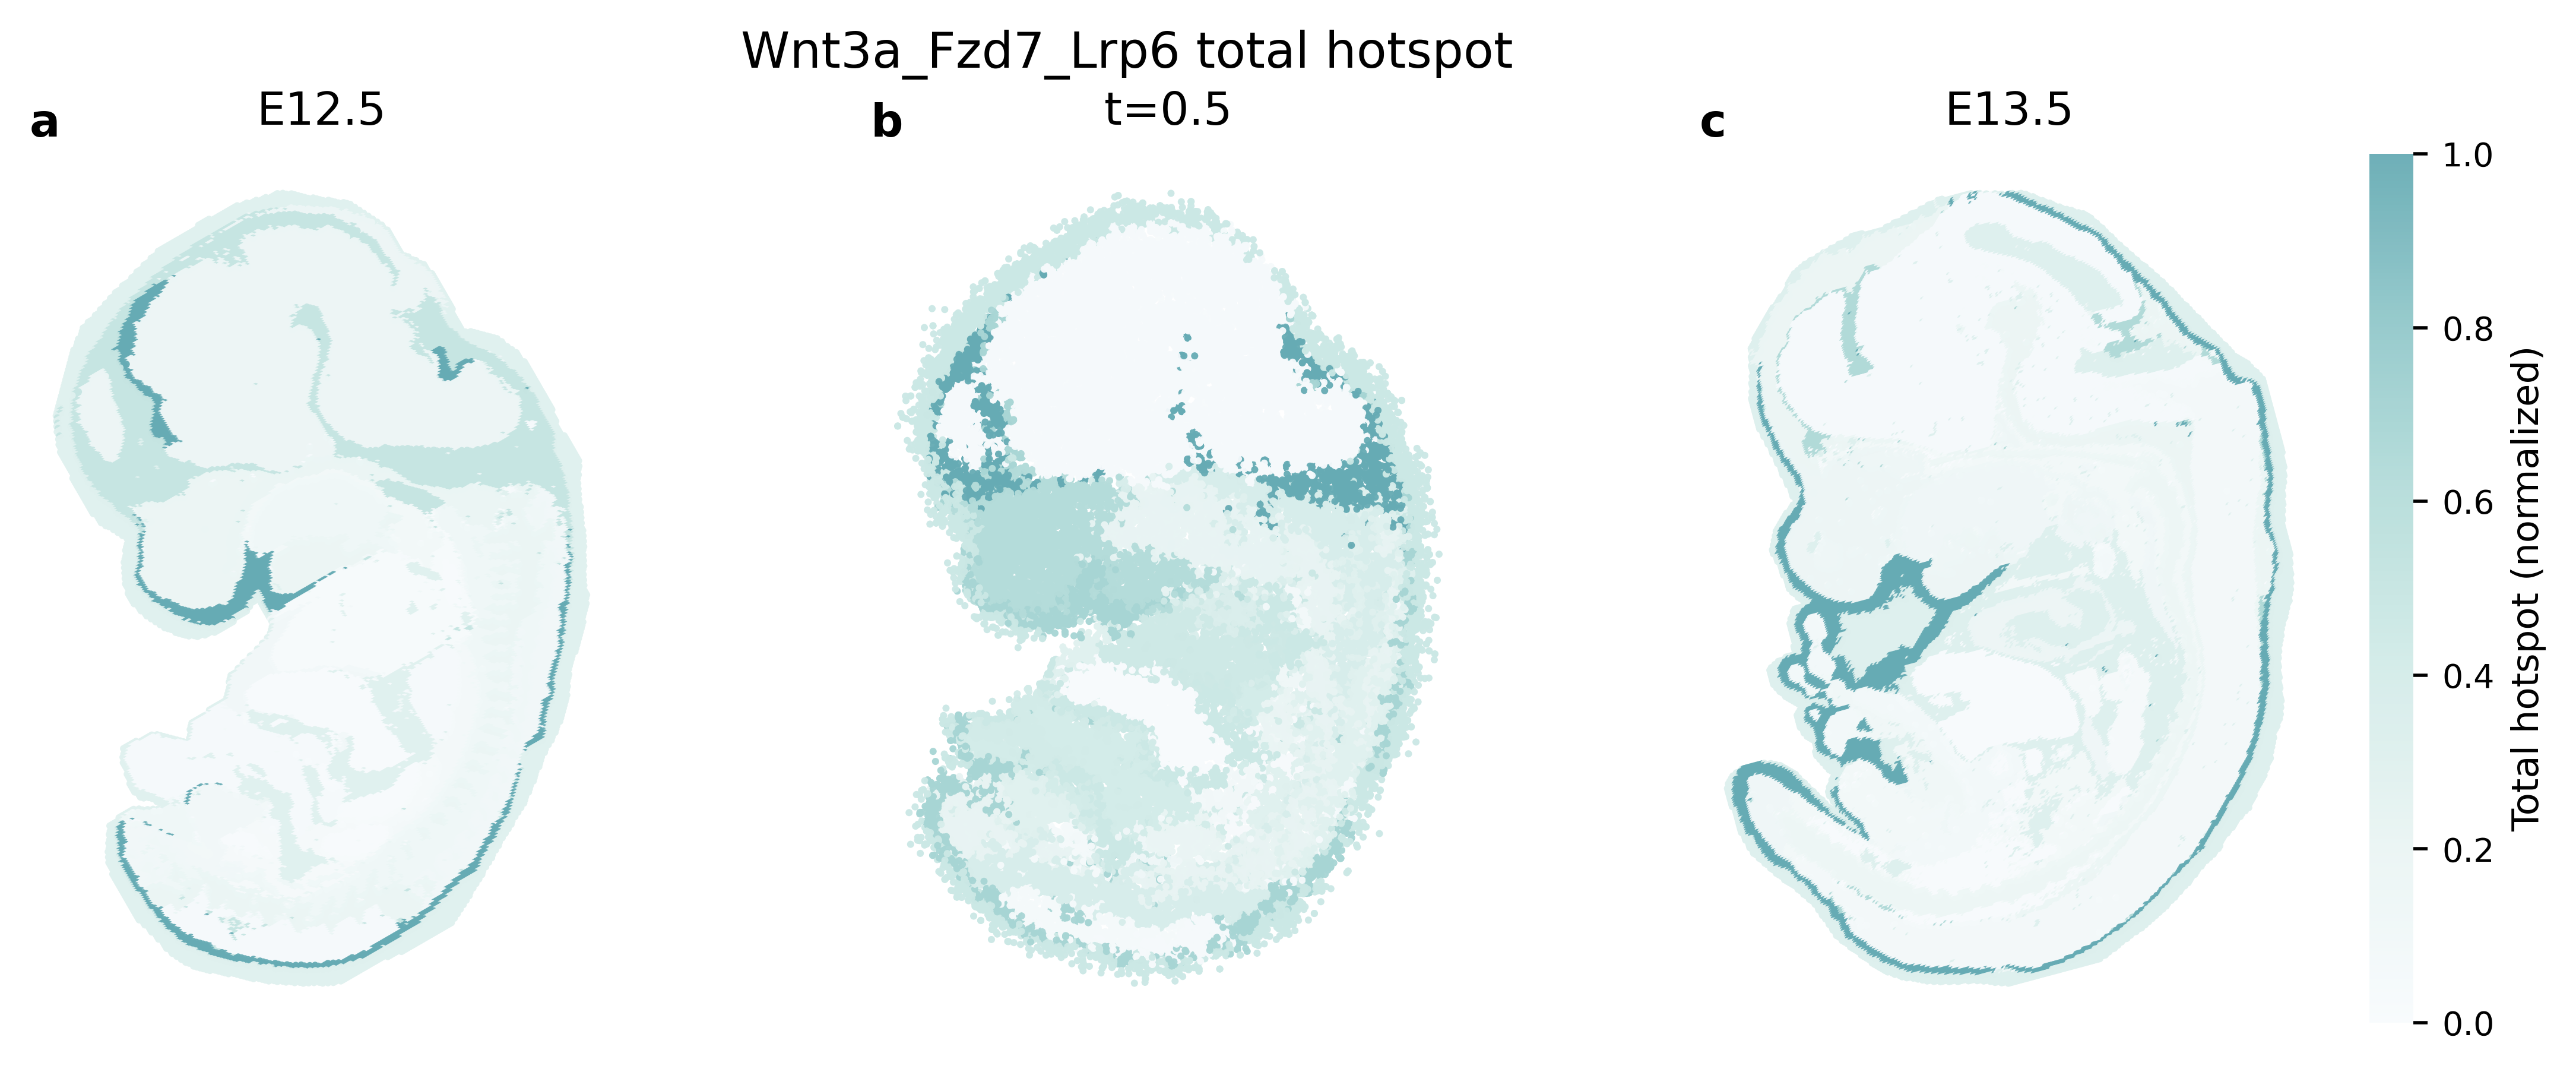

In [4]:
reference_stats = pd.read_csv(ASSET_DIR / MANIFEST['reference_stats_csv'])
display(reference_stats)
display(stats_df)
display(Image(filename=str(png_path)))
